In [15]:
import numpy as np
import matplotlib.pyplot as plt
import random as rand

Generated Dataset:
X values: [0.86736915 1.90880699 2.11694663 2.21956765 2.78111162 2.8937394
 2.93312429 3.15904831 3.39951572 3.71426784 3.84229682 3.91157653
 4.47250603 6.51734983 7.12373928 8.02335637 8.67946302 9.21324913
 9.26477435 9.30400136]
Y values: [9.71426285 5.10723968 1.74798554 2.62632016 4.06843727 1.91516851
 8.47547471 1.9669692  9.42005927 7.18029786 4.9638829  9.20273912
 5.5741296  9.20810957 7.13250753 9.28228682 9.01878184 1.36123275
 0.08970783 5.86223733] 

Estimated slope: -0.019711330176747997
Estimated intercept: 5.7908467221024456
Cubic Polynomial Coefficients: [-0.13579612  1.92315621 -7.22166615 12.79006739]
Linear Model MSE: 9.8744
Linear Model R²: 0.0003
Polynomial Model MSE: 6.0461
Polynomial Model R²: 0.3879

Performance Comparison:
Polynomial model performs better based on MSE
Polynomial model performs better based on R²


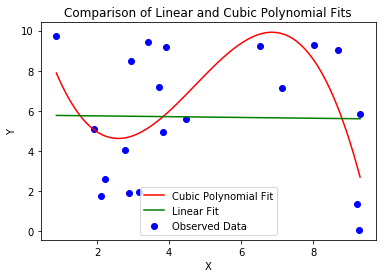

In [16]:
# Challenge A
def coded_least_square(x_vals, y_vals):
    n_points = len(x_vals)
    total_x = np.sum(x_vals)
    total_y = np.sum(y_vals)
    total_x2 = np.sum(x_vals**2)
    total_xy = np.sum(x_vals * y_vals)

    slope = (n_points * total_xy - total_x * total_y) / (n_points * total_x2 - (total_x)**2)
    intercept = (total_y - slope * total_x) / n_points
    return slope, intercept


# Random Data
x_random = np.random.uniform(0, 10, 20)
y_random = np.random.uniform(0, 10, 20)

sorted_index = np.argsort(x_random)
x_random = x_random[sorted_index]
y_random = y_random[sorted_index]

print("Generated Dataset:")
print("X values:", x_random)
print("Y values:", y_random, "\n")


# LINEAR
slope_val, intercept_val = least_square_solver(x_random, y_random)

print("Estimated slope:", slope_val)
print("Estimated intercept:", intercept_val)

y_linear_model = slope_val * x_random + intercept_val


# POLY
poly_coeffs = np.polyfit(x_random, y_random, 3)
poly_model = np.poly1d(poly_coeffs)

print("Cubic Polynomial Coefficients:", poly_coeffs)

y_poly_pred = poly_model(x_random)


# Linear Metrics
linear_mse = np.mean((y_random - y_linear_model)**2)
print(f"Linear Model MSE: {linear_mse:.4f}")

ss_total = np.sum((y_random - np.mean(y_random))**2)
ss_residual = np.sum((y_random - y_linear_model)**2)
linear_r2 = 1 - (ss_residual / ss_total)

print(f"Linear Model R²: {linear_r2:.4f}")


# Polynomial Metrics
poly_mse = np.mean((y_random - y_poly_pred)**2)
print(f"Polynomial Model MSE: {poly_mse:.4f}")

ss_total_poly = np.sum((y_random - np.mean(y_random))**2)
ss_res_poly = np.sum((y_random - y_poly_pred)**2)
poly_r2 = 1 - (ss_res_poly / ss_total_poly)

print(f"Polynomial Model R²: {poly_r2:.4f}")


# Model comparison
print("\nPerformance Comparison:")

if linear_mse < poly_mse:
    print("Linear model performs better based on MSE")
else:
    print("Polynomial model performs better based on MSE")

if linear_r2 > poly_r2:
    print("Linear model performs better based on R²")
else:
    print("Polynomial model performs better based on R²")


# Plot
x_range = np.linspace(min(x_random), max(x_random), 200)

y_poly_curve = poly_model(x_range)
y_linear_curve = slope_val * x_range + intercept_val

plt.scatter(x_random, y_random, color='blue', label='Observed Data')
plt.plot(x_range, y_poly_curve, color='red', label='Cubic Polynomial Fit')
plt.plot(x_range, y_linear_curve, color='green', label='Linear Fit')

plt.title("Comparison of Linear and Cubic Polynomial Fits")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

Linear Model Error (MSE): 9.8744
Linear Model R² Score: 0.0003
Polynomial Degree 3
MSE Value: 6.0461
R² Score: 0.3879

Polynomial Degree 4
MSE Value: 5.8288
R² Score: 0.4099

Polynomial Degree 5
MSE Value: 4.6796
R² Score: 0.5262

Polynomial Degree 6
MSE Value: 4.6793
R² Score: 0.5263

Polynomial Degree 7
MSE Value: 4.6492
R² Score: 0.5293

Polynomial Degree 8
MSE Value: 4.5693
R² Score: 0.5374

Polynomial Degree 9
MSE Value: 3.4681
R² Score: 0.6489

Polynomial Degree 10
MSE Value: 3.1580
R² Score: 0.6803



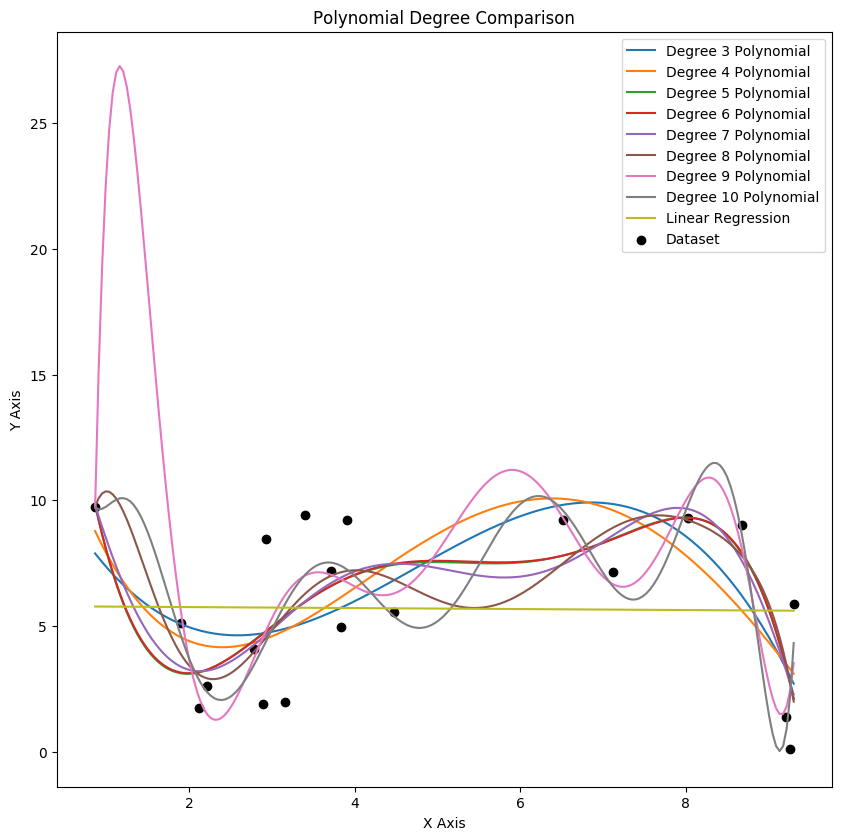

In [17]:
# Challenge B
plt.figure(figsize=(10,10), dpi=100)

# Linear model again
slope_val, intercept_val = least_square_solver(x_random, y_random)
y_linear_model = slope_val * x_random + intercept_val

linear_mse = np.mean((y_random - y_linear_model)**2)
print(f"Linear Model Error (MSE): {linear_mse:.4f}")

ss_total = np.sum((y_random - np.mean(y_random))**2)
ss_residual = np.sum((y_random - y_linear_model)**2)
linear_r2 = 1 - (ss_residual / ss_total)

print(f"Linear Model R² Score: {linear_r2:.4f}")


# Testing multiple polynomial degrees
for poly_degree in range(3, 11):

    coeffs = np.polyfit(x_random, y_random, poly_degree)
    poly_function = np.poly1d(coeffs)

    y_predicted = poly_function(x_random)

    poly_mse = np.mean((y_random - y_predicted)**2)

    ss_total_poly = np.sum((y_random - np.mean(y_random))**2)
    ss_res_poly = np.sum((y_random - y_predicted)**2)
    poly_r2 = 1 - (ss_res_poly / ss_total_poly)

    print(f"Polynomial Degree {poly_degree}")
    print(f"MSE Value: {poly_mse:.4f}")
    print(f"R² Score: {poly_r2:.4f}\n")

    x_range = np.linspace(min(x_random), max(x_random), 200)
    plt.plot(x_range, poly_function(x_range), label=f"Degree {poly_degree} Polynomial")

plt.plot(x_range, slope_val * x_range + intercept_val, label="Linear Regression")

plt.scatter(x_random, y_random, label="Dataset", color="black")

plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.title("Polynomial Degree Comparison")
plt.legend()
plt.show()

Vandermonde Polynomial Regression Results:

Polynomial Degree: 1
Computed Coefficients: [ 5.79084672 -0.01971133]
Mean Squared Error: 9.874416067399197
R² Score: 0.000295029158653648

Polynomial Degree: 2
Computed Coefficients: [ 2.47007356  1.60602763 -0.14690329]
Mean Squared Error: 9.255213958921328
R² Score: 0.06298424759704702

Polynomial Degree: 3
Computed Coefficients: [12.79006739 -7.22166615  1.92315621 -0.13579612]
Mean Squared Error: 6.0460506925790805
R² Score: 0.3878861402968956

Polynomial Degree: 4
Computed Coefficients: [ 17.47615035 -13.49654814   4.41612708  -0.50373453   0.01796554]
Mean Squared Error: 5.828766946368411
R² Score: 0.4098843667932447

Polynomial Degree: 5
Computed Coefficients: [ 3.37064238e+01 -4.29750376e+01  2.16353937e+01 -4.81417060e+00
  4.95445468e-01 -1.92183265e-02]
Mean Squared Error: 4.67962930120102
R² Score: 0.5262252833814738

Polynomial Degree: 6
Computed Coefficients: [ 3.29967717e+01 -4.14237379e+01  2.04811997e+01 -4.41844852e+00
  4.

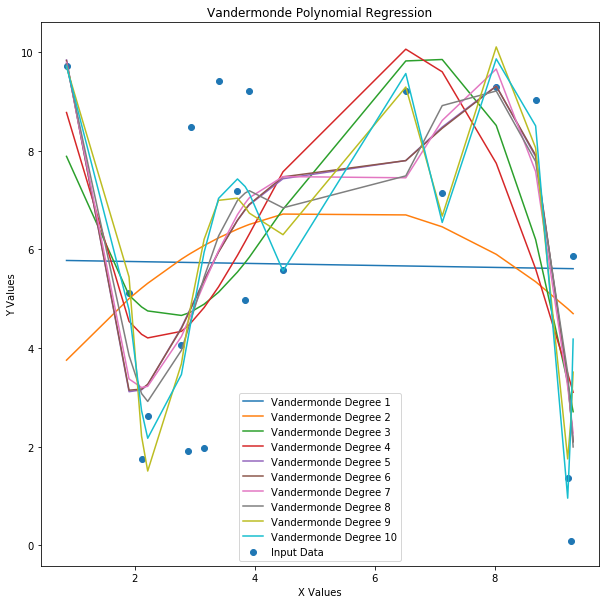

In [18]:
# Challenge C
plt.figure(figsize=(10,10))

plt.scatter(x_random, y_random, label="Input Data")


def build_vandermonde(input_x, degree):
    return np.vander(input_x, N=degree+1, increasing=True)


def vandermonde_solver(input_x, input_y, degree):

    matrix_v = build_vandermonde(input_x, degree)

    vt_v = np.dot(matrix_v.T, matrix_v)
    vt_y = np.dot(matrix_v.T, input_y)

    coeffs = np.linalg.solve(vt_v, vt_y)

    return coeffs


def make_prediction(input_x, coeffs):

    degree = len(coeffs) - 1

    matrix_v = build_vandermonde(input_x, degree)

    return np.dot(matrix_v, coeffs)


def evaluate_model(actual_y, predicted_y):

    mse_val = np.mean((actual_y - predicted_y)**2)

    ss_total = np.sum((actual_y - np.mean(actual_y))**2)
    ss_res = np.sum((actual_y - predicted_y)**2)

    r2_val = 1 - (ss_res / ss_total)

    return mse_val, r2_val


print("Vandermonde Polynomial Regression Results:\n")

for poly_degree in range(1,11):

    coeffs = vandermonde_solver(x_random, y_random, poly_degree)

    y_predicted = make_prediction(x_random, coeffs)

    mse_val, r2_val = evaluate_model(y_random, y_predicted)

    print("Polynomial Degree:", poly_degree)
    print("Computed Coefficients:", coeffs)
    print("Mean Squared Error:", mse_val)
    print("R² Score:", r2_val)
    print()

    plt.plot(x_random, y_predicted, label=f"Vandermonde Degree {poly_degree}")


plt.xlabel("X Values")
plt.ylabel("Y Values")
plt.title("Vandermonde Polynomial Regression")
plt.legend()
plt.show()